In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d

sys.path.insert(0, str((Path("..") / "src" / "utils").resolve()))
import visium_hd

from bosperrus import delaunay_edges, compute_centrality_measures, distance_to_convex_hull

plt.rcParams['svg.fonttype'] = 'none'

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import json
with open("../fit_palette.json", "r") as jsonfile: 
    pal = json.load(jsonfile)
blue = pal['Piecewise Linear Fit']

## Visium HD

Breast cancer (Fixed Frozen) sample: raw log1p total counts (row 1) and the
BOSPERRUS fit against distance to the nearest tissue-border spot (row 2).
`visium_hd.analyze_dataset` does its own internal `read_h5ad`, so the file
is read twice across this section; fine for exploratory use, not optimized
here.

In [4]:
VISIUM_BASE = "/home/woody/iwbn/iwbn007h/visium_hd_demo_data"
VISIUM_DATASETS = [
    {"name": "breast_cancer", "title": "Visium HD 8µm Breast cancer (Fixed Frozen)",
     "h5ad": f"{VISIUM_BASE}/Visium_HD_11mm_Human_Breast_Cancer/breast_cancer_008um_filtered.h5ad"}]

adata = visium_hd.read_h5ad(VISIUM_DATASETS[0]["h5ad"])
visium_result = visium_hd.analyze_dataset(VISIUM_DATASETS[0]["h5ad"])

INFO     Creating graph using `None` transform and `1` libraries.                                                  


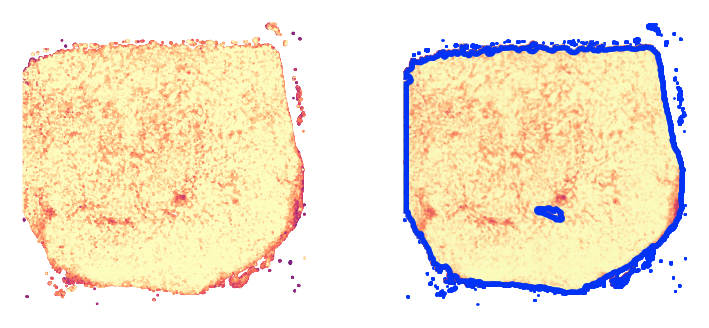

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
cmap = "magma"

axes[0].scatter(adata.obs["array_col"], adata.obs["array_row"], c=adata.obs["log1p_total_counts"],
                          s=0.5, rasterized=True, vmin=0, vmax=6, cmap=cmap)
axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].axis("off")

axes[1].scatter(adata.obs["array_col"], adata.obs["array_row"], c=blue,
                          s=0.5, rasterized=True)
visium_hd.plot_decision_boundary(axes[1], visium_result, measure="log1p_total_counts", cmap=cmap,
                        boundary_color=blue, boundary_alpha=0.1, title=None,
                        add_legend=False, vmin=0, vmax=6)
plt.savefig("../result_plots/figure2/analysi_buffer_overview.svg")